In [1]:
import os
import pandas as pd

base_path = "../../../data_c"  # cartella contenente le sottocartelle delle località
output_path = "output"

os.makedirs(output_path, exist_ok=True)

# mappa sensori → colonna finale
column_map = {
    "barometro": "barometer",
    "termometro": "temperature",
    "vento_scalare": "wind_speed",
    "vento_raffica": "wind_gust",
    "pluviometro": "rain_rate"
}

for location in os.listdir(base_path):
    loc_path = os.path.join(base_path, location)
    
    if not os.path.isdir(loc_path):
        continue

    print(f"Processing {location}...")

    merged_df = None

    for sensor_file in os.listdir(loc_path):
        sensor_name = os.path.splitext(sensor_file)[0]  # "barometro", "termometro", ...

        if sensor_name not in column_map:
            print(f"Skipped file {sensor_file}")
            continue
        
        sensor_path = os.path.join(loc_path, sensor_file)
        
        # legge il CSV
        df = pd.read_csv(sensor_path, sep=';')
        df.columns = ["Date", "Time", "Value", "Unit"]

        # corregge virgole decimali
        df["Value"] = df["Value"].astype(str).str.replace(",", ".").astype(float)
        
        # crea timestamp completo
        df["datetime"] = df["Date"] + " " + df["Time"]
        
        # rinomina colonna in inglese
        df = df[["datetime", "Value"]].rename(columns={"Value": column_map[sensor_name]})
        
        # merge con df principale
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on="datetime", how="outer")

    if merged_df is None:
        print(f"No sensor files found for {location}, skipping...")
        continue

    # split datetime in Date + Time
    merged_df[["Date", "Time"]] = merged_df["datetime"].str.split(" ", expand=True)
    merged_df = merged_df.drop(columns=["datetime"])

    # assicura che tutte le colonne siano presenti
    for col in column_map.values():
        if col not in merged_df.columns:
            merged_df[col] = pd.NA

    # ordina colonne
    ordered_cols = ["Date", "Time"] + list(column_map.values())
    merged_df = merged_df[ordered_cols]

    # salva CSV
    year = merged_df["Date"].iloc[0].split("-")[2]  # estrae anno da "01-01-2025"
    output_file = os.path.join(output_path, f"{year}_{location}.csv")
    merged_df.to_csv(output_file, sep=";", index=False)

    print(f"Saved → {output_file}")

Processing torriello...
Saved → output/2025_torriello.csv
Processing marcianise...
Saved → output/2025_marcianise.csv
Processing nisida...
Saved → output/2025_nisida.csv
Processing lago_patria...
Saved → output/2025_lago_patria.csv


In [2]:
import pandas as pd
import os

output_path = "output"

# lista dei file CSV
csv_files = [f for f in os.listdir(output_path) if f.endswith(".csv")]

dataframes = {}

for file in csv_files:
    file_path = os.path.join(output_path, file)
    df = pd.read_csv(file_path, sep=';')
    
    # salva in dizionario con chiave = nome località
    location_name = file.split("_")[1].replace(".csv", "")
    dataframes[location_name] = df
    
    # stampa info
    print(f"{location_name}: {df.shape[0]} rows, {df.shape[1]} columns")

marcianise: 52561 rows, 7 columns
lago: 52561 rows, 7 columns
torriello: 52561 rows, 7 columns
nisida: 52561 rows, 7 columns


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# pulizia rain_rate
for loc, df in dataframes.items():
    df["rain_rate"] = pd.to_numeric(df["rain_rate"], errors="coerce")

In [4]:
for loc, df in dataframes.items():
    df["datetime"] = pd.to_datetime(
        df["Date"] + " " + df["Time"],
        format="%d-%m-%Y %H:%M:%S",
        errors="coerce"
    )
    
    df["rain_rate"] = pd.to_numeric(df["rain_rate"], errors="coerce")

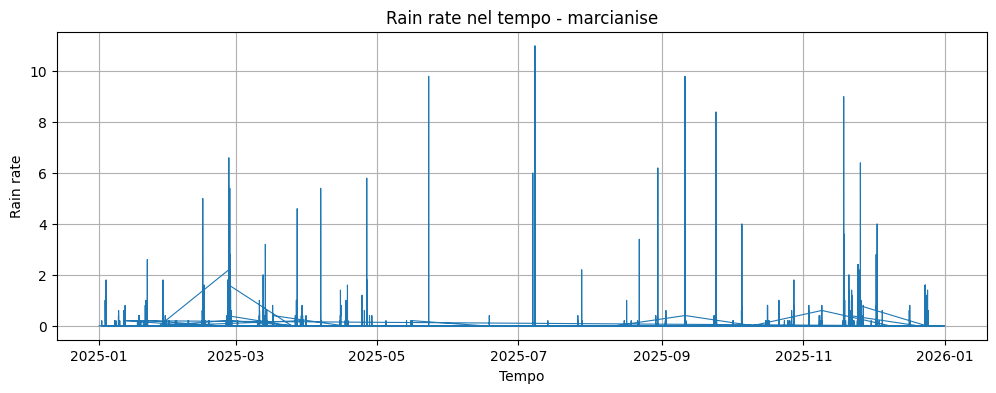

In [5]:
loc = "marcianise"

plt.figure(figsize=(12,4))
plt.plot(
    dataframes[loc]["datetime"],
    dataframes[loc]["rain_rate"],
    linewidth=0.8
)

plt.title(f"Rain rate nel tempo - {loc}")
plt.xlabel("Tempo")
plt.ylabel("Rain rate")
plt.grid(True)
plt.show()

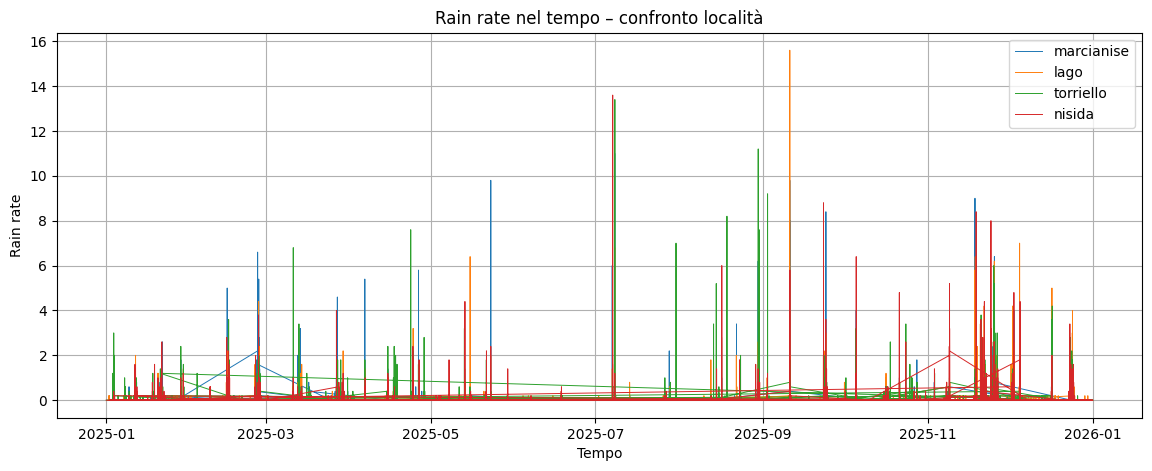

In [6]:
plt.figure(figsize=(14,5))

for loc, df in dataframes.items():
    plt.plot(
        df["datetime"],
        df["rain_rate"],
        label=loc,
        linewidth=0.7
    )

plt.title("Rain rate nel tempo – confronto località")
plt.xlabel("Tempo")
plt.ylabel("Rain rate")
plt.legend()
plt.grid(True)
plt.show()

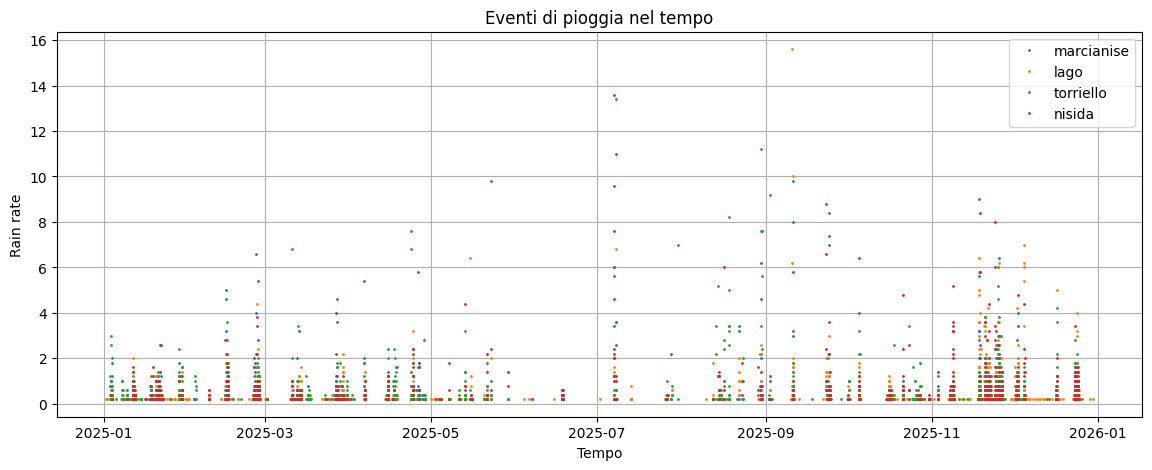

In [7]:
plt.figure(figsize=(14,5))

for loc, df in dataframes.items():
    rain = df[df["rain_rate"] > 0]
    plt.plot(
        rain["datetime"],
        rain["rain_rate"],
        ".",
        label=loc,
        markersize=2
    )

plt.title("Eventi di pioggia nel tempo")
plt.xlabel("Tempo")
plt.ylabel("Rain rate")
plt.legend()
plt.grid(True)
plt.show()

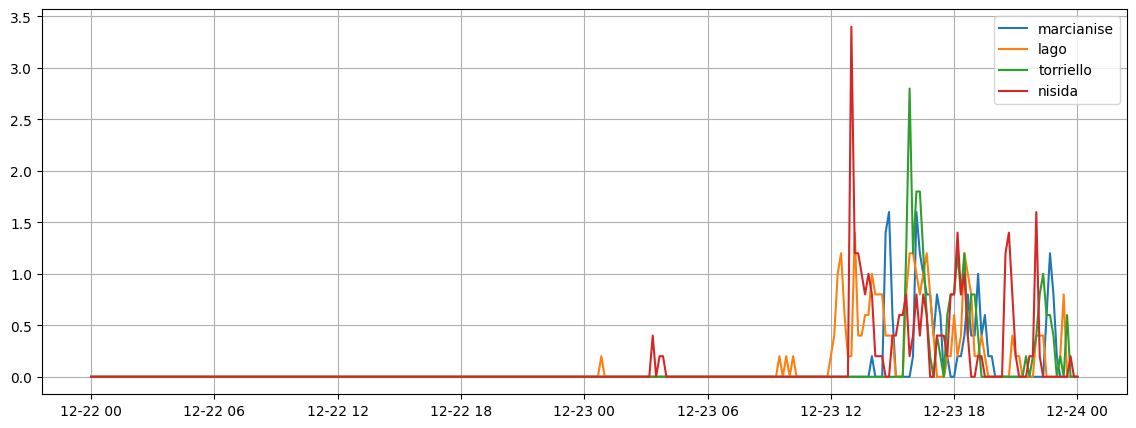

In [8]:
start = "2025-12-22"
end   = "2025-12-24"

plt.figure(figsize=(14,5))

for loc, df in dataframes.items():
    mask = (df["datetime"] >= start) & (df["datetime"] <= end)
    plt.plot(
        df.loc[mask, "datetime"],
        df.loc[mask, "rain_rate"],
        label=loc
    )

plt.legend()
plt.grid(True)
plt.show()

In [9]:
loc = "marcianise"
day = "2025-12-23"   # YYYY-MM-DD

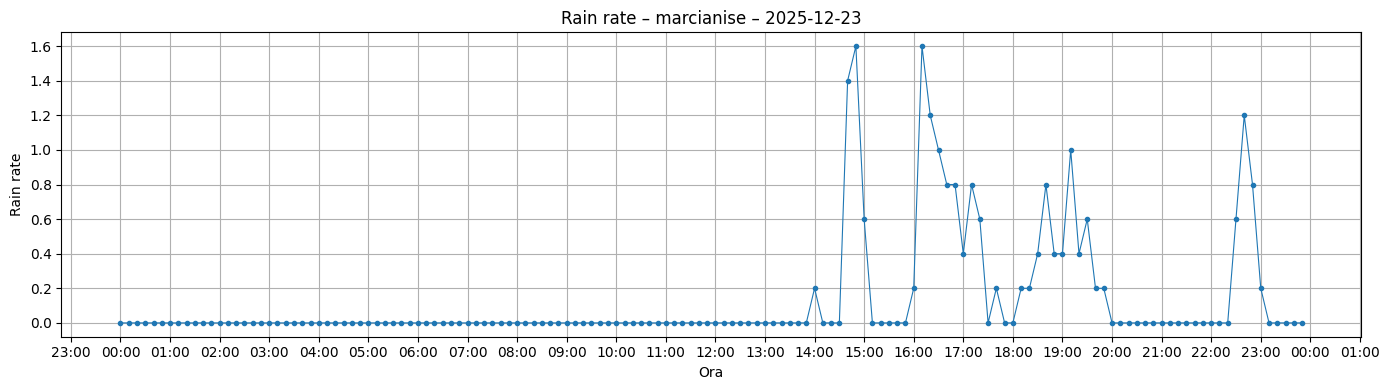

In [10]:
import matplotlib.dates as mdates

df = dataframes[loc]

# filtro sul giorno
mask = df["datetime"].dt.date == pd.to_datetime(day).date()
df_day = df.loc[mask]

plt.figure(figsize=(14,4))
plt.plot(
    df_day["datetime"],
    df_day["rain_rate"],
    marker="o",
    linestyle="-",
    linewidth=0.8,
    markersize=3
)

plt.title(f"Rain rate – {loc} – {day}")
plt.xlabel("Ora")
plt.ylabel("Rain rate")
plt.grid(True)

# formattazione asse X (ore)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.tight_layout()
plt.show()

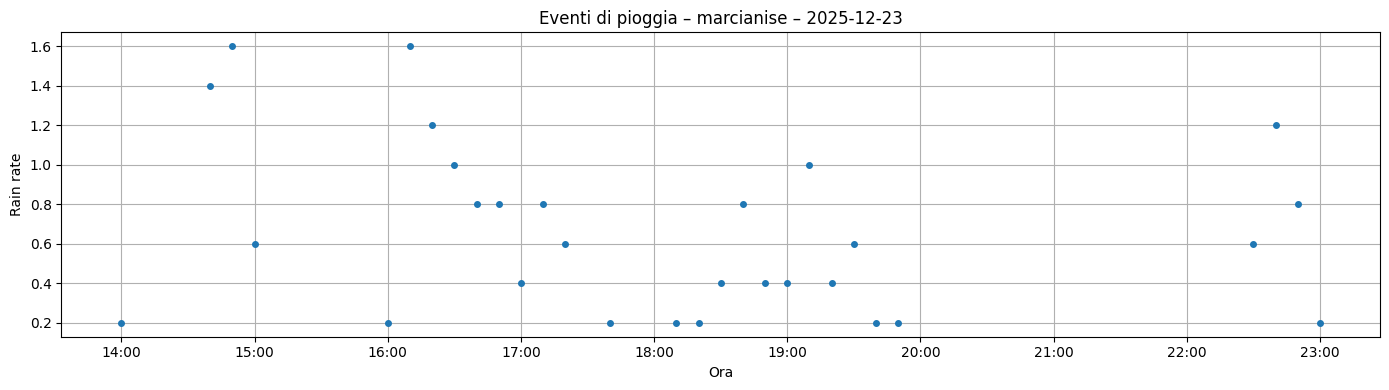

In [11]:
df_rain = df_day[df_day["rain_rate"] > 0]

plt.figure(figsize=(14,4))
plt.plot(
    df_rain["datetime"],
    df_rain["rain_rate"],
    "o",
    markersize=4
)

plt.title(f"Eventi di pioggia – {loc} – {day}")
plt.xlabel("Ora")
plt.ylabel("Rain rate")
plt.grid(True)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.tight_layout()
plt.show()

In [12]:
dataframes["nisida"]

,Date,Time,barometer,temperature,wind_speed,wind_gust,rain_rate,datetime
0,01-01-2025,00:00:00,1021.1,11.5,2.5,3.4,NaN,2025-01-01 00:00:00
1,01-01-2025,00:10:00,1021.1,11.5,2.4,NaN,0.0,2025-01-01 00:10:00
2,01-01-2025,00:20:00,1021.1,11.6,2.0,NaN,0.0,2025-01-01 00:20:00
3,01-01-2025,00:30:00,1021.0,11.7,1.6,NaN,0.0,2025-01-01 00:30:00
4,01-01-2025,00:40:00,1020.9,11.5,1.4,NaN,0.0,2025-01-01 00:40:00
...,...,...,...,...,...,...,...,...
52556,31-12-2025,23:10:00,1008.7,4.8,4.4,NaN,0.0,2025-12-31 23:10:00
52557,31-12-2025,23:20:00,1008.9,4.5,3.0,NaN,0.0,2025-12-31 23:20:00
52558,31-12-2025,23:30:00,1008.8,4.3,2.5,NaN,0.0,2025-12-31 23:30:00
52559,31-12-2025,23:40:00,1008.8,4.7,3.1,NaN,0.0,2025-12-31 23:40:00


In [13]:
dataframes["marcianise"]

,Date,Time,barometer,temperature,wind_speed,wind_gust,rain_rate,datetime
0,01-01-2025,00:00:00,1029.3,4.9,0.0,1.5,NaN,2025-01-01 00:00:00
1,01-01-2025,00:10:00,1029.2,5.0,0.6,NaN,0.0,2025-01-01 00:10:00
2,01-01-2025,00:20:00,1029.2,5.0,0.9,NaN,0.0,2025-01-01 00:20:00
3,01-01-2025,00:30:00,1029.1,4.7,0.2,NaN,0.0,2025-01-01 00:30:00
4,01-01-2025,00:40:00,1028.9,4.6,0.0,NaN,0.0,2025-01-01 00:40:00
...,...,...,...,...,...,...,...,...
52556,31-12-2025,23:10:00,1017.2,4.7,1.7,NaN,0.0,2025-12-31 23:10:00
52557,31-12-2025,23:20:00,1017.2,4.8,1.7,NaN,0.0,2025-12-31 23:20:00
52558,31-12-2025,23:30:00,1017.2,5.2,2.4,NaN,0.0,2025-12-31 23:30:00
52559,31-12-2025,23:40:00,1017.2,4.9,2.7,NaN,0.0,2025-12-31 23:40:00


In [14]:
dataframes["lago"]

,Date,Time,barometer,temperature,wind_speed,wind_gust,rain_rate,datetime
0,01-01-2025,00:00:00,1032.7,3.0,1.1,1.6,NaN,2025-01-01 00:00:00
1,01-01-2025,00:10:00,1032.7,3.0,1.3,NaN,0.0,2025-01-01 00:10:00
2,01-01-2025,00:20:00,1032.6,3.0,1.2,NaN,0.0,2025-01-01 00:20:00
3,01-01-2025,00:30:00,1032.6,3.0,1.5,NaN,0.0,2025-01-01 00:30:00
4,01-01-2025,00:40:00,1032.5,2.9,1.5,NaN,0.0,2025-01-01 00:40:00
...,...,...,...,...,...,...,...,...
52556,31-12-2025,23:10:00,1020.8,0.5,2.2,NaN,0.0,2025-12-31 23:10:00
52557,31-12-2025,23:20:00,1020.8,0.5,1.8,NaN,0.0,2025-12-31 23:20:00
52558,31-12-2025,23:30:00,1020.8,0.7,1.3,NaN,0.0,2025-12-31 23:30:00
52559,31-12-2025,23:40:00,1020.6,0.0,1.6,NaN,0.0,2025-12-31 23:40:00


In [15]:
dataframes["torriello"]

,Date,Time,barometer,temperature,wind_speed,wind_gust,rain_rate,datetime
0,01-01-2025,00:00:00,933.2,7.3,0.0,0.0,NaN,2025-01-01 00:00:00
1,01-01-2025,00:10:00,933.3,7.4,0.0,NaN,0.0,2025-01-01 00:10:00
2,01-01-2025,00:20:00,933.2,7.1,0.0,NaN,0.0,2025-01-01 00:20:00
3,01-01-2025,00:30:00,933.1,7.2,0.0,NaN,0.0,2025-01-01 00:30:00
4,01-01-2025,00:40:00,933.0,7.1,1.0,NaN,0.0,2025-01-01 00:40:00
...,...,...,...,...,...,...,...,...
52556,31-12-2025,23:10:00,920.0,-1.6,7.4,NaN,0.0,2025-12-31 23:10:00
52557,31-12-2025,23:20:00,920.0,-1.5,4.4,NaN,0.0,2025-12-31 23:20:00
52558,31-12-2025,23:30:00,919.9,-1.5,7.1,NaN,0.0,2025-12-31 23:30:00
52559,31-12-2025,23:40:00,919.8,-1.5,5.3,NaN,0.0,2025-12-31 23:40:00


In [16]:
for loc, df in dataframes.items():
    print(f"\n{loc}")
    print(df.isna().sum())


marcianise
Date               0
Time               0
barometer         12
temperature        8
wind_speed         8
wind_gust      43803
rain_rate          1
datetime           0
dtype: int64

lago
Date               0
Time               0
barometer        136
temperature       20
wind_speed        22
wind_gust      43804
rain_rate          1
datetime           0
dtype: int64

torriello
Date               0
Time               0
barometer       1056
temperature        4
wind_speed         5
wind_gust      43810
rain_rate          3
datetime           0
dtype: int64

nisida
Date               0
Time               0
barometer         24
temperature       24
wind_speed        24
wind_gust      43804
rain_rate          1
datetime           0
dtype: int64


In [17]:
for loc, df in dataframes.items():
    total = len(df)
    zeros = (df["rain_rate"] == 0).sum()
    perc = zeros / total * 100

    print(f"{loc}: rain_rate = 0 → {zeros} ({perc:.2f}%)")

marcianise: rain_rate = 0 → 51314 (97.63%)
lago: rain_rate = 0 → 51315 (97.63%)
torriello: rain_rate = 0 → 50883 (96.81%)
nisida: rain_rate = 0 → 51349 (97.69%)


In [18]:
summary = []

for loc, df in dataframes.items():
    valid = df["rain_rate"].notna().sum()
    zeros = (df["rain_rate"] == 0).sum()

    summary.append({
        "località": loc,
        "valori_validi": valid,
        "rain_rate_0": zeros,
        "percentuale_%": zeros / valid * 100
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

     località  valori_validi  rain_rate_0  percentuale_%
0  marcianise          52560        51314      97.629376
1        lago          52560        51315      97.631279
2   torriello          52558        50883      96.813045
3      nisida          52560        51349      97.695967


In [19]:
def extract_events(df, threshold=0.1, threshold_range=pd.Timedelta("30min")):
    df = df.sort_values("datetime").reset_index(drop=True)

    events = []
    current_event = []
    last_above_time = None
    event_open = False

    for _, row in df.iterrows():
        rain = row["rain_rate"]
        time = row["datetime"]

        if pd.notna(rain) and rain > threshold:
            current_event.append(row)
            last_above_time = time
            event_open = True

        else:
            if event_open:
                if last_above_time is not None and (time - last_above_time) <= threshold_range:
                    current_event.append(row)
                else:
                    events.append(pd.DataFrame(current_event))
                    current_event = []
                    event_open = False

    if event_open and current_event:
        events.append(pd.DataFrame(current_event))

    if events:
        event_df = pd.concat(events, ignore_index=True)
    else:
        event_df = pd.DataFrame(columns=df.columns)

    return event_df, events

In [20]:
events_by_location = {}

for loc, df in dataframes.items():
    event_df, events = extract_events(
        df,
        threshold=0.1,
        threshold_range=pd.Timedelta("30min")
    )
    
    events_by_location[loc] = events
    print(f"{loc}: {len(events)} eventi estratti")

marcianise: 247 eventi estratti
lago: 299 eventi estratti
torriello: 338 eventi estratti
nisida: 242 eventi estratti


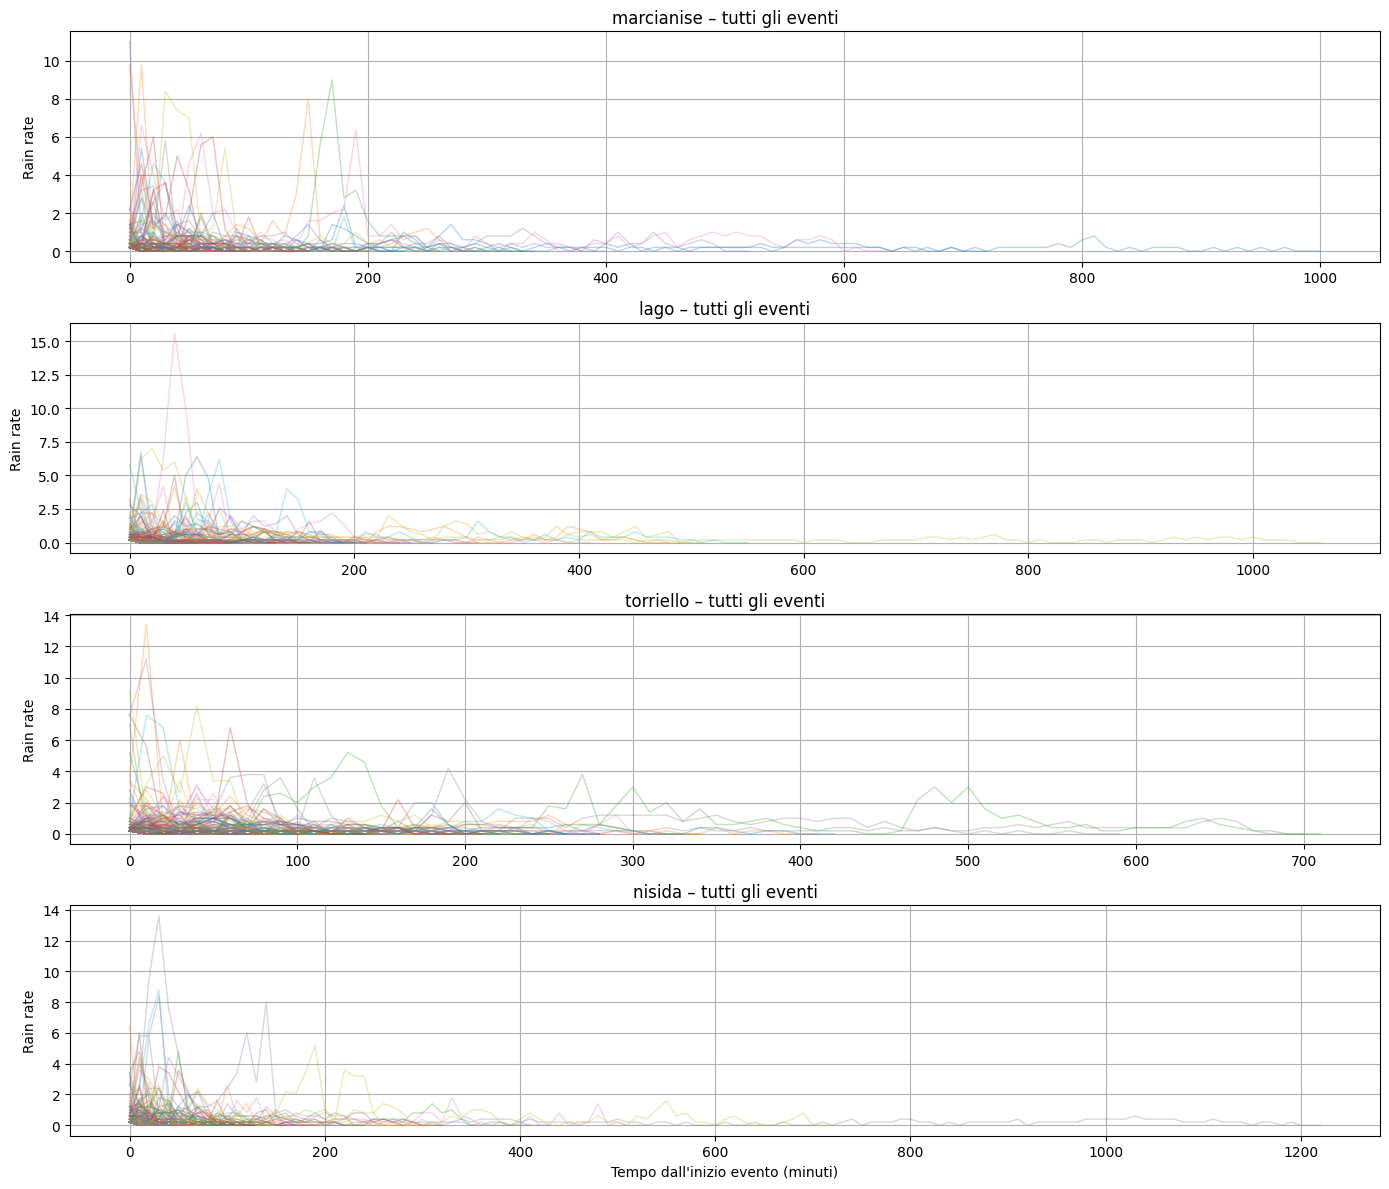

In [21]:
import matplotlib.pyplot as plt

n_loc = len(events_by_location)

fig, axes = plt.subplots(
    n_loc, 1,
    figsize=(14, 3 * n_loc),
    sharex=False
)

if n_loc == 1:
    axes = [axes]

for ax, (loc, events) in zip(axes, events_by_location.items()):

    for ev in events:
        # tempo relativo (minuti dall'inizio evento)
        t0 = ev["datetime"].iloc[0]
        t_rel = (ev["datetime"] - t0).dt.total_seconds() / 60

        ax.plot(
            t_rel,
            ev["rain_rate"],
            alpha=0.3,
            linewidth=1
        )

    ax.set_title(f"{loc} – tutti gli eventi")
    ax.set_ylabel("Rain rate")
    ax.grid(True)

axes[-1].set_xlabel("Tempo dall'inizio evento (minuti)")
plt.tight_layout()
plt.show()

In [22]:
loc = "marcianise"
event_range_start = 100
event_range_end = 120   # escluso (come slicing Python)

In [23]:
events = events_by_location[loc][event_range_start:event_range_end]

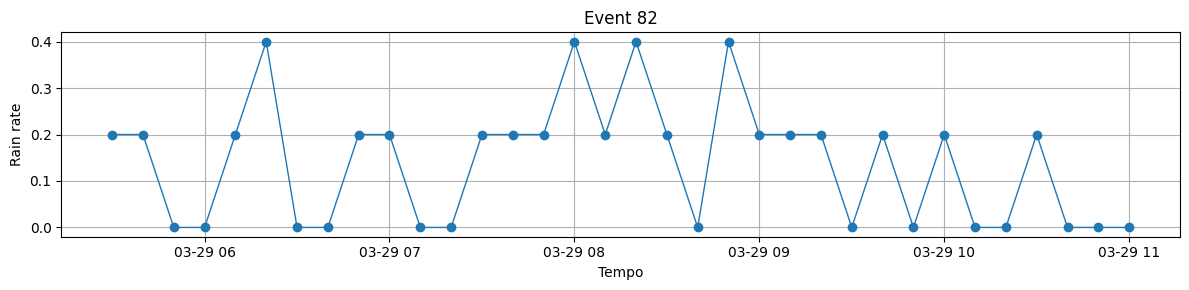

In [53]:
import matplotlib.pyplot as plt

# parametri
loc = "marcianise"
event_range_start = 82
event_range_end   = 83

# prendi gli eventi della località
events = events_by_location[loc][event_range_start:event_range_end]

# numero di eventi da plottare
n_events = len(events)

# crea figura con n subplot verticali
fig, axes = plt.subplots(n_events, 1, figsize=(12, 3*n_events), sharex=False)

# se c'è un solo evento, axes non è lista
if n_events == 1:
    axes = [axes]

for ax, i, ev in zip(axes, range(event_range_start, event_range_end), events):
    ax.plot(ev["datetime"], ev["rain_rate"], marker="o", linestyle="-", linewidth=1)
    ax.set_title(f"Event {i}")
    ax.set_ylabel("Rain rate")
    ax.grid(True)

axes[-1].set_xlabel("Tempo")
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

summary = []

for loc, events in events_by_location.items():
    # concatena tutti gli eventi in un unico DataFrame
    all_events_df = pd.concat(events, ignore_index=True)
    
    # totale valori validi
    valid_count = all_events_df["rain_rate"].notna().sum()
    
    # NaN count
    nan_count = all_events_df["rain_rate"].isna().sum()
    
    # rain_rate = 0
    zeros_count = (all_events_df["rain_rate"] == 0).sum()
    
    # percentuale di rain_rate=0 sui valori validi
    zeros_perc = zeros_count / valid_count * 100 if valid_count > 0 else 0
    
    summary.append({
        "località": loc,
        "NaN_count": nan_count,
        "total_values": len(all_events_df),
        "rain_rate_0_count": zeros_count,
        "percent_rain_rate_0_%": zeros_perc
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

     località  NaN_count  total_values  rain_rate_0_count  \
0  marcianise          0          2376               1130   
1        lago          0          2437               1192   
2   torriello          0          3168               1493   
3      nisida          0          2225               1014   

   percent_rain_rate_0_%  
0              47.558923  
1              48.912597  
2              47.127525  
3              45.573034  


In [26]:
events_by_location["nisida"][0].shape

(4, 8)

In [27]:
nisida_all_events = pd.concat(events_by_location["nisida"], ignore_index=True)
nisida_all_events.shape

(2225, 8)

In [28]:
summary_events = []

for loc, events in events_by_location.items():
    # concatena tutti gli eventi in un unico DataFrame
    all_events_df = pd.concat(events, ignore_index=True)
    
    # conteggio NaN
    nan_count = all_events_df["rain_rate"].isna().sum()
    
    # conteggio valori validi
    valid_count = all_events_df["rain_rate"].notna().sum()
    
    # conteggio rain_rate = 0
    zeros_count = (all_events_df["rain_rate"] == 0).sum()
    
    # percentuale rain_rate = 0 sui valori validi
    zeros_perc = zeros_count / valid_count * 100 if valid_count > 0 else 0
    
    summary_events.append({
        "località": loc,
        "righe_eventi": len(all_events_df),
        "NaN_count": nan_count,
        "rain_rate_0_count": zeros_count,
        "percent_rain_rate_0_%": zeros_perc
    })

summary_events_df = pd.DataFrame(summary_events)
print(summary_events_df)

     località  righe_eventi  NaN_count  rain_rate_0_count  \
0  marcianise          2376          0               1130   
1        lago          2437          0               1192   
2   torriello          3168          0               1493   
3      nisida          2225          0               1014   

   percent_rain_rate_0_%  
0              47.558923  
1              48.912597  
2              47.127525  
3              45.573034  


In [29]:
nan_summary = []

for loc, events in events_by_location.items():
    # concatena tutti gli eventi in un unico DataFrame
    all_events_df = pd.concat(events, ignore_index=True)
    
    # conta NaN per ogni colonna
    nan_counts = all_events_df.isna().sum()
    
    # aggiunge località
    nan_counts["località"] = loc
    
    nan_summary.append(nan_counts)

# crea un DataFrame finale
nan_summary_df = pd.DataFrame(nan_summary)

# metti località come prima colonna
cols = ["località"] + [c for c in nan_summary_df.columns if c != "località"]
nan_summary_df = nan_summary_df[cols]

print(nan_summary_df)

     località  Date  Time  barometer  temperature  wind_speed  wind_gust  \
0  marcianise     0     0          0            0           0       1973   
1        lago     0     0          3            0           0       2022   
2   torriello     0     0         75            0           0       2648   
3      nisida     0     0          1            1           1       1853   

   rain_rate  datetime  
0          0         0  
1          0         0  
2          0         0  
3          0         0  


In [30]:
cols_to_keep = ["Date", "Time", "barometer", "temperature", "wind_speed", "rain_rate", "datetime"]

# pulizia degli eventi: eliminiamo le colonne extra
for loc, events in events_by_location.items():
    for i, ev in enumerate(events):
        # mantieni solo le colonne nella lista
        events[i] = ev[cols_to_keep].copy()  # importante copy() per evitare warning

# ora facciamo il conteggio dei NaN solo sulle colonne rimaste
nan_summary_filtered = []

for loc, events in events_by_location.items():
    # concatena tutti gli eventi della località in un unico DataFrame
    all_events_df = pd.concat(events, ignore_index=True)
    
    # conta i NaN solo per le colonne selezionate
    nan_counts = all_events_df.isna().sum()
    
    # aggiungi località
    nan_counts["località"] = loc
    
    nan_summary_filtered.append(nan_counts)

# Crea DataFrame finale
nan_summary_df = pd.DataFrame(nan_summary_filtered)

# riordina le colonne per avere 'località' come prima
cols = ["località"] + [c for c in nan_summary_df.columns if c != "località"]
nan_summary_df = nan_summary_df[cols]

print(nan_summary_df)

     località  Date  Time  barometer  temperature  wind_speed  rain_rate  \
0  marcianise     0     0          0            0           0          0   
1        lago     0     0          3            0           0          0   
2   torriello     0     0         75            0           0          0   
3      nisida     0     0          1            1           1          0   

   datetime  
0         0  
1         0  
2         0  
3         0  


In [31]:
# for loc, events in events_by_location.items():
#     for i, ev in enumerate(events):
#         # solo colonne numeriche
#         num_cols = ["barometer", "temperature", "wind_speed", "wind_gust", "rain_rate"]
#         # interpolazione lineare
#         events[i][num_cols] = events[i][num_cols].interpolate(method="linear", limit_direction="both")

In [32]:
# window = 3  # numero di misure (es. 3 = 30 minuti se campionamento 10 min)
# for loc, events in events_by_location.items():
#     for i, ev in enumerate(events):
#         num_cols = ["barometer", "temperature", "wind_speed", "wind_gust", "rain_rate"]
#         events[i][num_cols] = events[i][num_cols].interpolate(method="linear", limit_direction="both")
#         # rolling mean
#         events[i][num_cols] = events[i][num_cols].rolling(window, min_periods=1, center=True).mean()

In [33]:
import pandas as pd

# colonne numeriche su cui fare interpolazione
num_cols = ["barometer", "temperature", "wind_speed"]

# finestra rolling media (in numero di righe)
window = 3  # esempio: 3 punti → 30 minuti se campionamento 10 min

for loc, events in events_by_location.items():
    for i, ev in enumerate(events):
        # interpolazione lineare dei NaN
        # limit_direction="both" permette di riempire NaN all'inizio e fine
        ev[num_cols] = ev[num_cols].interpolate(method="linear", limit_direction="both")
        
        # rolling mean per lisciare i dati (opzionale)
        ev[num_cols] = ev[num_cols].rolling(window=window, min_periods=1, center=True).mean()
        
        # assegna di nuovo all'evento
        events[i] = ev

In [34]:
nan_summary = []

for loc, events in events_by_location.items():
    # concatena tutti gli eventi in un unico DataFrame
    all_events_df = pd.concat(events, ignore_index=True)
    
    # conta NaN per ogni colonna
    nan_counts = all_events_df.isna().sum()
    
    # aggiunge località
    nan_counts["località"] = loc
    
    nan_summary.append(nan_counts)

# crea un DataFrame finale
nan_summary_df = pd.DataFrame(nan_summary)

# metti località come prima colonna
cols = ["località"] + [c for c in nan_summary_df.columns if c != "località"]
nan_summary_df = nan_summary_df[cols]

print(nan_summary_df)

     località  Date  Time  barometer  temperature  wind_speed  rain_rate  \
0  marcianise     0     0          0            0           0          0   
1        lago     0     0          0            0           0          0   
2   torriello     0     0          0            0           0          0   
3      nisida     0     0          0            0           0          0   

   datetime  
0         0  
1         0  
2         0  
3         0  


In [35]:
events_by_location['marcianise']

[           Date      Time    barometer  temperature  wind_speed  rain_rate  \
 160  02-01-2025  02:40:00  1025.700000     4.550000    0.900000        0.2   
 161  02-01-2025  02:50:00  1025.666667     4.633333    0.766667        0.0   
 162  02-01-2025  03:00:00  1025.533333     4.600000    0.500000        0.0   
 163  02-01-2025  03:10:00  1025.500000     4.550000    0.300000        0.0   
 
                datetime  
 160 2025-01-02 02:40:00  
 161 2025-01-02 02:50:00  
 162 2025-01-02 03:00:00  
 163 2025-01-02 03:10:00  ,
            Date      Time    barometer  temperature  wind_speed  rain_rate  \
 370  03-01-2025  13:40:00  1012.700000    13.250000    5.600000        1.0   
 371  03-01-2025  13:50:00  1012.633333    13.066667    5.166667        0.2   
 372  03-01-2025  14:00:00  1012.566667    12.800000    4.600000        0.2   
 373  03-01-2025  14:10:00  1012.600000    12.666667    4.133333        0.4   
 374  03-01-2025  14:20:00  1012.666667    12.600000    3.533333        

In [36]:
events_by_location['nisida']

[           Date      Time    barometer  temperature  wind_speed  rain_rate  \
 393  03-01-2025  17:30:00  1004.250000    12.400000    9.000000        0.4   
 394  03-01-2025  17:40:00  1004.233333    12.433333    9.266667        0.0   
 395  03-01-2025  17:50:00  1004.200000    12.466667    9.200000        0.0   
 396  03-01-2025  18:00:00  1004.200000    12.500000    9.700000        0.0   
 
                datetime  
 393 2025-01-03 17:30:00  
 394 2025-01-03 17:40:00  
 395 2025-01-03 17:50:00  
 396 2025-01-03 18:00:00  ,
            Date      Time    barometer  temperature  wind_speed  rain_rate  \
 415  03-01-2025  21:10:00  1004.550000    14.600000        8.85        0.2   
 416  03-01-2025  21:20:00  1004.533333    14.600000        8.70        0.0   
 417  03-01-2025  21:30:00  1004.466667    14.633333        8.40        0.0   
 418  03-01-2025  21:40:00  1004.450000    14.650000        8.55        0.0   
 
                datetime  
 415 2025-01-03 21:10:00  
 416 2025-01-03 

In [37]:
events_by_location['lago']

[           Date      Time    barometer  temperature  wind_speed  rain_rate  \
 123  01-01-2025  20:30:00  1030.200000     5.050000    1.700000        0.2   
 124  01-01-2025  20:40:00  1030.233333     4.933333    1.733333        0.0   
 125  01-01-2025  20:50:00  1030.266667     4.700000    1.800000        0.0   
 126  01-01-2025  21:00:00  1030.300000     4.550000    1.850000        0.0   
 
                datetime  
 123 2025-01-01 20:30:00  
 124 2025-01-01 20:40:00  
 125 2025-01-01 20:50:00  
 126 2025-01-01 21:00:00  ,
            Date      Time    barometer  temperature  wind_speed  rain_rate  \
 169  02-01-2025  04:10:00  1028.600000     4.650000    2.400000        0.2   
 170  02-01-2025  04:20:00  1028.533333     4.566667    2.133333        0.0   
 171  02-01-2025  04:30:00  1028.433333     4.433333    1.800000        0.0   
 172  02-01-2025  04:40:00  1028.350000     4.350000    1.650000        0.0   
 
                datetime  
 169 2025-01-02 04:10:00  
 170 2025-01-02 

In [38]:
events_by_location['torriello']

[           Date      Time   barometer  temperature  wind_speed  rain_rate  \
 337  03-01-2025  08:10:00  921.600000     6.000000    4.450000        0.4   
 338  03-01-2025  08:20:00  921.566667     6.033333    3.566667        0.8   
 339  03-01-2025  08:30:00  921.466667     6.133333    3.200000        0.2   
 340  03-01-2025  08:40:00  921.466667     6.266667    2.933333        0.0   
 341  03-01-2025  08:50:00  921.466667     6.366667    3.133333        0.8   
 342  03-01-2025  09:00:00  921.433333     6.466667    2.866667        1.2   
 343  03-01-2025  09:10:00  921.400000     6.566667    2.266667        0.4   
 344  03-01-2025  09:20:00  921.433333     6.700000    2.733333        0.6   
 345  03-01-2025  09:30:00  921.633333     6.766667    2.933333        0.0   
 346  03-01-2025  09:40:00  921.733333     6.833333    2.733333        0.0   
 347  03-01-2025  09:50:00  921.800000     6.850000    2.200000        0.0   
 
                datetime  
 337 2025-01-03 08:10:00  
 338 202

In [39]:
import pandas as pd

nan_summary = []

for loc, events in events_by_location.items():
    # concatena tutti gli eventi della località in un unico DataFrame
    all_events_df = pd.concat(events, ignore_index=True)
    
    # conta i NaN su tutte le colonne
    nan_counts = all_events_df.isna().sum()
    
    # aggiungi località come colonna
    nan_counts["località"] = loc
    
    nan_summary.append(nan_counts)

# crea DataFrame finale
nan_summary_df = pd.DataFrame(nan_summary)

# riordina colonne per avere 'località' come prima
cols = ["località"] + [c for c in nan_summary_df.columns if c != "località"]
nan_summary_df = nan_summary_df[cols]

print(nan_summary_df)

     località  Date  Time  barometer  temperature  wind_speed  rain_rate  \
0  marcianise     0     0          0            0           0          0   
1        lago     0     0          0            0           0          0   
2   torriello     0     0          0            0           0          0   
3      nisida     0     0          0            0           0          0   

   datetime  
0         0  
1         0  
2         0  
3         0  


In [40]:
import pandas as pd

# Definisci le località e il loro ID
station_ids = {
    "marcianise": 1,
    "lago": 2,
    "torriello": 3,
    "nisida": 4
}

# Lista dove salvare tutti i DataFrame degli eventi con station_id
all_events_list = []

for loc, events in events_by_location.items():
    for ev in events:
        # aggiungi colonna station_id
        ev_copy = ev.copy()  # copiamo per sicurezza
        ev_copy["station_id"] = station_ids[loc]
        all_events_list.append(ev_copy)

# concatena tutti gli eventi in un unico DataFrame
all_events_df = pd.concat(all_events_list, ignore_index=True)

# Salva in CSV (puoi cambiare sep=';' se vuoi)
all_events_df.to_csv("events_dataset.csv", sep=";", index=False)

print("Salvataggio completato: events_dataset.csv")


Salvataggio completato: events_dataset.csv


In [41]:
events_df = pd.read_csv("../../../data/events_dataset.csv", sep=";")
events_df

,Date,Time,barometer,temperature,wind_speed,rain_rate,datetime,station_id
0,02-01-2025,02:40:00,1025.700000,4.550000,0.900000,0.2,2025-01-02 02:40:00,1
1,02-01-2025,02:50:00,1025.666667,4.633333,0.766667,0.0,2025-01-02 02:50:00,1
2,02-01-2025,03:00:00,1025.533333,4.600000,0.500000,0.0,2025-01-02 03:00:00,1
3,02-01-2025,03:10:00,1025.500000,4.550000,0.300000,0.0,2025-01-02 03:10:00,1
4,03-01-2025,13:40:00,1012.700000,13.250000,5.600000,1.0,2025-01-03 13:40:00,1
...,...,...,...,...,...,...,...,...
10201,25-12-2025,04:20:00,1001.550000,11.550000,3.600000,0.0,2025-12-25 04:20:00,4
10202,25-12-2025,06:00:00,1001.750000,12.550000,3.800000,0.2,2025-12-25 06:00:00,4
10203,25-12-2025,06:10:00,1001.766667,12.533333,3.900000,0.0,2025-12-25 06:10:00,4
10204,25-12-2025,06:20:00,1001.866667,12.533333,4.066667,0.0,2025-12-25 06:20:00,4


In [42]:
import numpy as np
from sklearn.preprocessing import StandardScaler

num_cols = ["barometer", "temperature", "wind_speed"]
scaler = StandardScaler()
events_df[num_cols] = scaler.fit_transform(events_df[num_cols])

events_df["rain_rate"] = np.log1p(events_df["rain_rate"])

# parsing datetime
events_df["datetime"] = pd.to_datetime(
    events_df["Date"] + " " + events_df["Time"],
    format="%d-%m-%Y %H:%M:%S"
)

# feature temporali
events_df["hour"] = events_df["datetime"].dt.hour
events_df["hour_sin"] = np.sin(2*np.pi*events_df["hour"]/24)
events_df["hour_cos"] = np.cos(2*np.pi*events_df["hour"]/24)

events_df["month"] = events_df["datetime"].dt.month
events_df["month_sin"] = np.sin(2*np.pi*events_df["month"]/12)
events_df["month_cos"] = np.cos(2*np.pi*events_df["month"]/12)

events_df.to_csv("../../../data/events_dataset_scaled.csv", sep=";", index=False)
print("Salvataggio completato: events_dataset_scaled.csv")

Salvataggio completato: events_dataset_scaled.csv


In [43]:
events_df_scaled = pd.read_csv("../../../data/events_dataset_scaled.csv", sep=";")
events_df_scaled

,Date,Time,barometer,temperature,wind_speed,rain_rate,datetime,station_id,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,02-01-2025,02:40:00,1.100274,-1.602177,-1.120952,0.182322,2025-01-02 02:40:00,1,2,0.500000,8.660254e-01,1,5.000000e-01,0.866025
1,02-01-2025,02:50:00,1.099496,-1.584655,-1.181152,0.000000,2025-01-02 02:50:00,1,2,0.500000,8.660254e-01,1,5.000000e-01,0.866025
2,02-01-2025,03:00:00,1.096383,-1.591664,-1.301551,0.000000,2025-01-02 03:00:00,1,3,0.707107,7.071068e-01,1,5.000000e-01,0.866025
3,02-01-2025,03:10:00,1.095605,-1.602177,-1.391850,0.000000,2025-01-02 03:10:00,1,3,0.707107,7.071068e-01,1,5.000000e-01,0.866025
4,03-01-2025,13:40:00,0.796784,0.227217,1.001081,0.693147,2025-01-03 13:40:00,1,13,-0.258819,-9.659258e-01,1,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10201,25-12-2025,04:20:00,0.536483,-0.130251,0.098088,0.000000,2025-12-25 04:20:00,4,4,0.866025,5.000000e-01,12,-2.449294e-16,1.000000
10202,25-12-2025,06:00:00,0.541152,0.080025,0.188387,0.182322,2025-12-25 06:00:00,4,6,1.000000,6.123234e-17,12,-2.449294e-16,1.000000
10203,25-12-2025,06:10:00,0.541541,0.076520,0.233537,0.000000,2025-12-25 06:10:00,4,6,1.000000,6.123234e-17,12,-2.449294e-16,1.000000
10204,25-12-2025,06:20:00,0.543876,0.076520,0.308787,0.000000,2025-12-25 06:20:00,4,6,1.000000,6.123234e-17,12,-2.449294e-16,1.000000


In [44]:
import joblib

joblib.dump(scaler, "scaler_features.pkl")

['scaler_features.pkl']

In [45]:
scaler = joblib.load("scaler_features.pkl")
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


<Axes: >

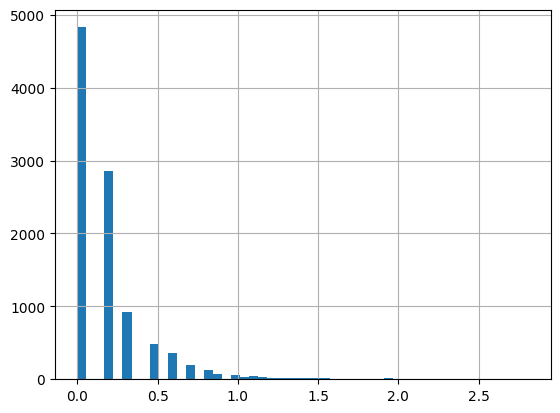

In [46]:
events_df["rain_rate"].hist(bins=50)

In [47]:
(events_df["rain_rate"] > 0).mean()

np.float64(0.5268469527728787)